<a href="https://colab.research.google.com/github/pabzpcz/PDI/blob/main/LPDI_7_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize #Algoritmos como SLSQP para valores optimos

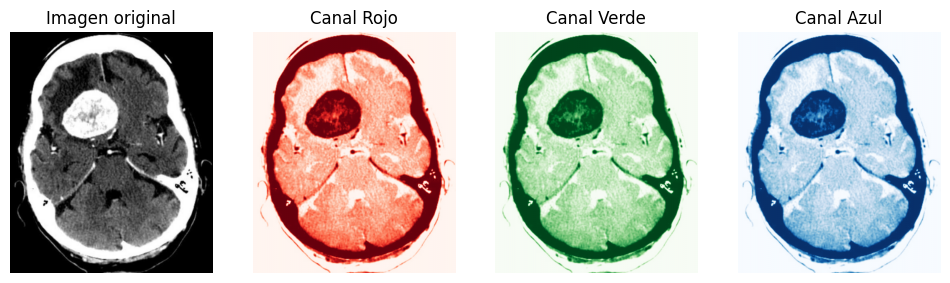

In [4]:
img = cv2.imread('/content/I7 LPDI.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

R = img_rgb[:,:,0]
G = img_rgb[:,:,1]
B = img_rgb[:,:,2]

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(R, cmap='Reds')
plt.title('Canal Rojo')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(G, cmap='Greens')
plt.title('Canal Verde')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(B, cmap='Blues')
plt.title('Canal Azul')
plt.axis('off')
plt.show()

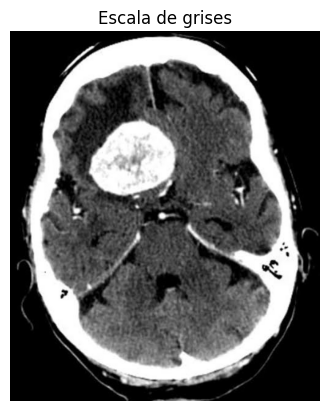

In [5]:
#Calculo escala de grises promedio
gray_avg = ((R.astype(np.float32) + G + B) / 3).astype(np.uint8)

plt.imshow(gray_avg, cmap='gray')
plt.title('Escala de grises')
plt.axis('off')
plt.show()

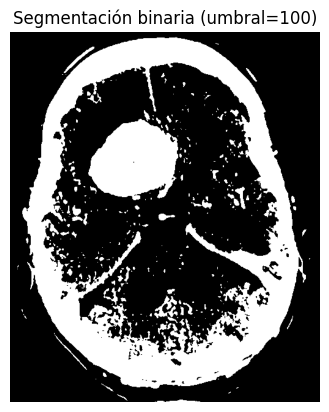

In [6]:
#Umbral de segmentación
umbral = 100
_, segmentada = cv2.threshold(gray_avg, umbral, 255, cv2.THRESH_BINARY)

plt.imshow(segmentada, cmap='gray')
plt.title(f'Segmentación binaria (umbral={umbral})')
plt.axis('off')
plt.show()

#Segmentación Óptima

In [7]:
img = cv2.imread('/content/I7 LPDI.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

In [8]:
# Normalizar canales entre 0 y 1
R_norm = R.astype(np.float32) / 255
G_norm = G.astype(np.float32) / 255
B_norm = B.astype(np.float32) / 255

# Función objetivo: varianza negativa (porque minimize() minimiza)
def grayscale_variance(weights):
    w_r, w_g, w_b = weights
    gray = w_r * R_norm + w_g * G_norm + w_b * B_norm
    gray_normalized = (gray - gray.min()) / (gray.max() - gray.min())
    return -np.var(gray_normalized)  # Negativo para maximizar

# Restricción: suma de pesos debe ser 1
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

# Límites de cada peso: entre 0 y 1
bounds = [(0, 1), (0, 1), (0, 1)]

# Valor inicial
initial_weights = [0.33, 0.33, 0.34]

# Optimización
result = minimize(grayscale_variance, initial_weights, method='SLSQP',
                  bounds=bounds, constraints=constraints)

optimal_weights = result.x
print("Pesos óptimos:", optimal_weights)

Pesos óptimos: [0.33 0.33 0.34]


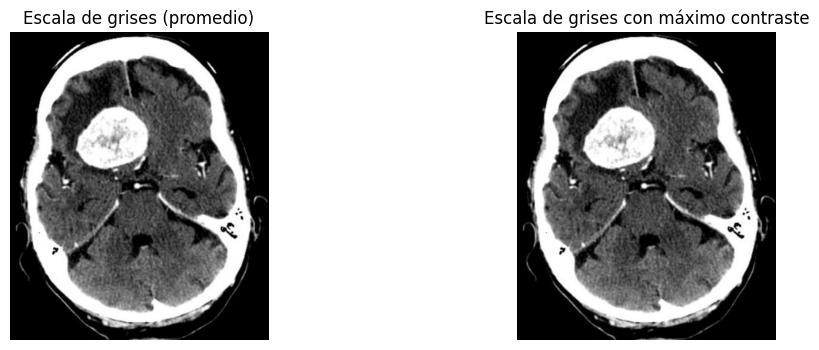

In [9]:
# Crear imagen en escala de grises con pesos óptimos
gray_optimal = optimal_weights[0] * R_norm + optimal_weights[1] * G_norm + optimal_weights[2] * B_norm
gray_optimal = (gray_optimal * 255).astype(np.uint8)

# Imagen obtenida de manera directa o sencilla
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray_avg, cmap='gray')
plt.title('Escala de grises (promedio)')
plt.axis('off')

# Imagen obtenida de manera óptima
plt.subplot(1, 2, 2)
plt.imshow(gray_optimal, cmap='gray')
plt.title('Escala de grises con máximo contraste')
plt.axis('off')
plt.show()

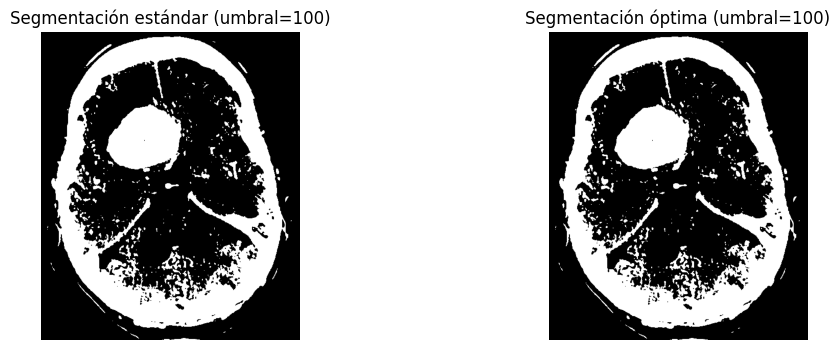

In [10]:
# Segmentar ambas imágenes con un mismo umbral
umbral = 100
_, seg_standard = cv2.threshold(gray_avg, umbral, 255, cv2.THRESH_BINARY)
_, seg_optimal = cv2.threshold(gray_optimal, umbral, 255, cv2.THRESH_BINARY)

# Mostrar resultado
# Imagen obtenida de manera directa o sencilla
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(seg_standard, cmap='gray')
plt.title(f'Segmentación estándar (umbral={umbral})')
plt.axis('off')

# Imagen obtenida de manera óptima
plt.subplot(1, 2, 2)
plt.imshow(seg_optimal, cmap='gray')
plt.title(f'Segmentación óptima (umbral={umbral})')
plt.axis('off')
plt.show()

#Eliminación de Ruido

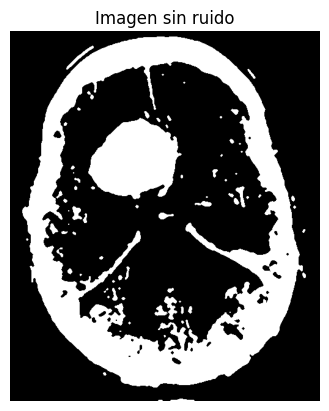

In [11]:
kernel = np.ones((3,3), np.uint8)
# eliminar ruido pequeño
imgLimpia = cv2.morphologyEx(seg_optimal, cv2.MORPH_OPEN, kernel)
# cerrar huecos
imgLimpia = cv2.morphologyEx(imgLimpia, cv2.MORPH_CLOSE, kernel)
# suavizado
imgLimpia = cv2.medianBlur(imgLimpia, 5)

# mostrar resultado
plt.imshow(imgLimpia,cmap='gray')
plt.title('Imagen sin ruido')
plt.axis('off')
plt.show()

#Detección de Contornos y Área del Tumor

Área estimada del tumor: 13632.0 px


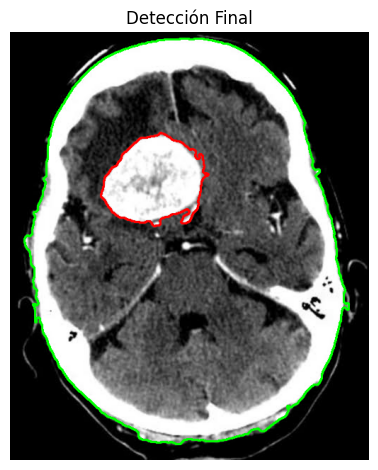

In [12]:
#Análisis de bordes y calculo de area
contours, _ = cv2.findContours(imgLimpia, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
area_total = img_rgb.shape[0] * img_rgb.shape[1]

#Seleccion del craneo y del tumor
lista_craneo = sorted(filter(lambda c: cv2.contourArea(c) > area_total * 0.40, contours), key=cv2.contourArea)[-1:]
lista_tumor = sorted(filter(lambda c: area_total * 0.01 < cv2.contourArea(c) < area_total * 0.30, contours), key=cv2.contourArea)[-1:]

#Crea copia de la imagen
visual_result = img_rgb.copy()

#Dibuja los contornos
cv2.drawContours(visual_result, lista_craneo, -1, (0, 255, 0), 2)  # Cráneo (borde verde)
cv2.drawContours(visual_result, lista_tumor, -1, (255, 0, 0), 2)   # Tumor (borde rojo)

#Area del tumor
area_tumor = sum(map(cv2.contourArea, lista_tumor))
print(f"Área estimada del tumor: {area_tumor} px")

plt.imshow(visual_result)
plt.title("Detección Final")
plt.axis('off')
plt.tight_layout()
plt.show()